# Поліноміальна регресія та регуляризація
Поліноми - вирази, до яких входять цілі ступені змінної: 
$\sum_{i=0}^{N}a_i\cdot x^i$

Ступенем полінома називають його максимальний ступінь $N$, при $N=1$ маємо лінію (лінійну регресію).
При більших ступенях мова іде про нелінійну регресію.

## Завдання 1
Перевірте, як поліноміальні ознаки впливають на якість моделі:
- Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
- Побудуйте модель лінійної регресії на вихідних даних.
- Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
- Навчіть модель на розширеному наборі ознак.
- Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.

In [16]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

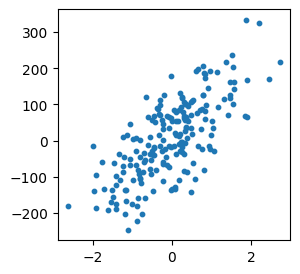

In [24]:
# Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
X, y = make_regression(n_samples=200, n_features=1, noise=75, random_state=42)
_,ax = plt.subplots(figsize=(3,3))
ax.scatter(X, y, s=10)
plt.show()

In [25]:
# Побудуйте модель лінійної регресії на вихідних даних.
model1 = LinearRegression()
model1.fit(X,y)

# Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
model2 = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model2.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


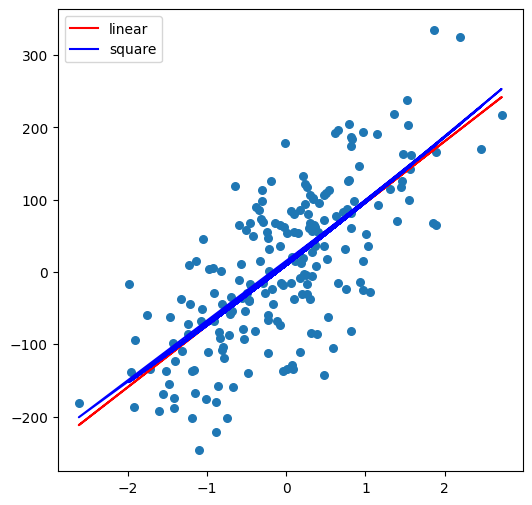

In [38]:
# Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.
_,ax = plt.subplots(figsize=(6,6))
ax.scatter(X, y, s=30)
ax.plot(X, model1.predict(X), '-r', label='linear')
ax.plot(X, model2.predict(X), '-b', label='square')
ax.legend()
plt.show()

## Завдання 2
Порівняйте моделі з різним ступенем полінома і проаналізуйте перенавчання:
- Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).
- Побудуйте моделі для ступенів полінома: 2, 5, 10.
- Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
- Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
- Оформіть результати в таблиці:

|Ступінь полінома|R² навч.|R² тест.|
|-|-|-|
|2|...|...|
|5|...|...|
|10|...|...|

In [30]:
# Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20)
X2, y2 = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
# Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [33]:
# Побудуйте моделі для ступенів полінома: 2, 5, 10.
degrees = [2, 5, 10]
models = [
    make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )
    for d in degrees
]
for m in models:
    m.fit(xtrain, ytrain)

In [36]:
# Для кожної моделі обчисліть R² на навчальній і тестовій вибірках
from IPython.display import Markdown as md
import sklearn.metrics as sm

r2_train = [sm.r2_score(ytrain, m.predict(xtrain)) for m in models]
r2_test  = [sm.r2_score(ytest,  m.predict(xtest))  for m in models]

md("\n".join((
    "|Ступінь полінома|R² навч.|R² тест.|",
    "|-|-|-|",
    *(f"|{degrees[i]}|{r2_train[i]}|{r2_test[i]}|" for i in range(len(degrees)))
)))

|Ступінь полінома|R² навч.|R² тест.|
|-|-|-|
|2|0.9399759367954303|0.9449541323633316|
|5|0.9415912035254085|0.886133123794706|
|10|0.9428972243032762|-31.840955119114362|

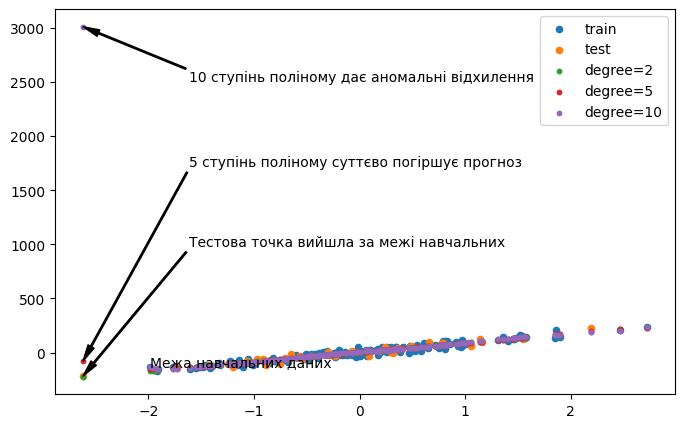

In [77]:
# візуалізуємо результати
predictions = [m.predict(X2) for m in models]

_,ax = plt.subplots(figsize=(8,5))
ax.scatter(xtrain, ytrain, s=20, label='train')
ax.scatter(xtest, ytest, s=20, label='test')
for i in range(len(degrees)):
    ax.scatter(X2, predictions[i], s=10, label=f'degree={degrees[i]}')
#for i in range(len(xtrain)):
#    ax.annotate(f"{i}", (xtrain[i][0], ytrain[i]))
ax.annotate(
    "Межа навчальних даних", 
    (xtrain[65][0], ytrain[65])
)
ax.annotate(
    "Тестова точка вийшла за межі навчальних", 
    (xtest[15][0], ytest[15]), 
    (xtest[15][0] + 1, ytest[15] + 1200),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)
ax.annotate(
    "5 ступінь поліному суттєво погіршує прогноз", 
    (xtest[15][0], predictions[1][177]), 
    (xtest[15][0] + 1, predictions[1][177] + 1800),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)
ax.annotate(
    "10 ступінь поліному дає аномальні відхилення", 
    (xtest[15][0], predictions[2][177]), 
    (xtest[15][0] + 1, predictions[2][177] - 500),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)
ax.legend()
plt.show()

Негативні наслідки поліноміальної регресії - "хвости" - поведінка поза межами навчальної послідовності.
Чим вище ступінь поліному, тим швидше він зростає (або спадає у мінус) з віддаленням від "центру"